# 02 — Parametric Geometry

**MANTA** — BWB Flying Wing with integrated EDF propulsion

1. Design variables & derived geometry
2. CAD 3-view drawing (top, side, front, airfoils)
3. Duct performance & clearance

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src.parameterization.design_variables import BWBParams, BOUNDS, VAR_NAMES, N_VARS
from src.parameterization.bwb_aircraft import (
    compute_wing_area, compute_aspect_ratio, compute_mac,
    compute_internal_volume, estimate_structural_mass, body_height_at_xc,
)
from src.propulsion.edf_model import EDF_70MM
from src.propulsion.duct_geometry import size_and_place_duct, validate_duct_clearance
from src.config import load_all, duct_from_config, load_config
from src.visualization.style import apply_style
apply_style()

%load_ext autoreload
%autoreload 2

cfg = load_all()
mission = cfg['mission']
duct_cfg = duct_from_config(load_config())
params = BWBParams()

In [2]:
s_ref = compute_wing_area(params)
ar = compute_aspect_ratio(params)
mac = compute_mac(params)

print(f"{'═'*60}")
print(f"  MANTA BWB — {N_VARS} design variables")
print(f"{'═'*60}")
print(f"  Mission    : V={mission.velocity} m/s, MTOW={mission.mtow} kg, payload={mission.payload_mass*1000:.0f}g")
print(f"  Planform   : span={2*params.half_span:.2f}m, S={s_ref*1e4:.0f}cm2, AR={ar:.2f}, MAC={mac*1000:.0f}mm")
print(f"  Body       : chord={params.body_root_chord*1000:.0f}mm, t/c={params.body_tc_root:.1%}, width={2*params.body_halfwidth*1000:.0f}mm")
print(f"  Wing       : root={params.wing_root_chord*1000:.0f}mm, tip={params.tip_chord*1000:.0f}mm, taper={params.taper_ratio}, sweep={params.le_sweep_deg:.0f}deg")
print(f"  Structure  : mass={estimate_structural_mass(params, mtow=mission.mtow):.3f}kg, volume={compute_internal_volume(params)*1e6:.0f}cm3")
print(f"  Loading    : {mission.mtow / s_ref:.1f} kg/m2")
print()
print(f"  {'Variable':<28s} {'Lo':>7s} {'Default':>8s} {'Hi':>7s}")
print(f"  {'─'*52}")
for name in VAR_NAMES:
    lo, hi = BOUNDS[name]
    print(f"  {name:<28s} {lo:7.3f} {getattr(params, name):8.3f} {hi:7.3f}")

════════════════════════════════════════════════════════════
  MANTA BWB — 32 design variables
════════════════════════════════════════════════════════════
  Mission    : V=25.0 m/s, MTOW=2.5 kg, payload=200g
  Planform   : span=1.50m, S=4252cm2, AR=5.29, MAC=285mm
  Body       : chord=588mm, t/c=18.1%, width=240mm
  Wing       : root=420mm, tip=63mm, taper=0.15, sweep=26deg
  Structure  : mass=0.708kg, volume=2346cm3
  Loading    : 5.9 kg/m2

  Variable                          Lo  Default      Hi
  ────────────────────────────────────────────────────
  half_span                      0.550    0.750   1.000
  wing_root_chord                0.250    0.420   0.550
  taper_ratio                    0.080    0.150   0.400
  le_sweep_deg                  18.000   26.000  35.000
  body_chord_ratio               1.100    1.400   2.000
  body_halfwidth                 0.080    0.120   0.250
  body_kulfan_u2                 0.250    0.456   0.650
  body_kulfan_u6                 0.100    0.240  

## Geometry — CAD 3-View Drawing

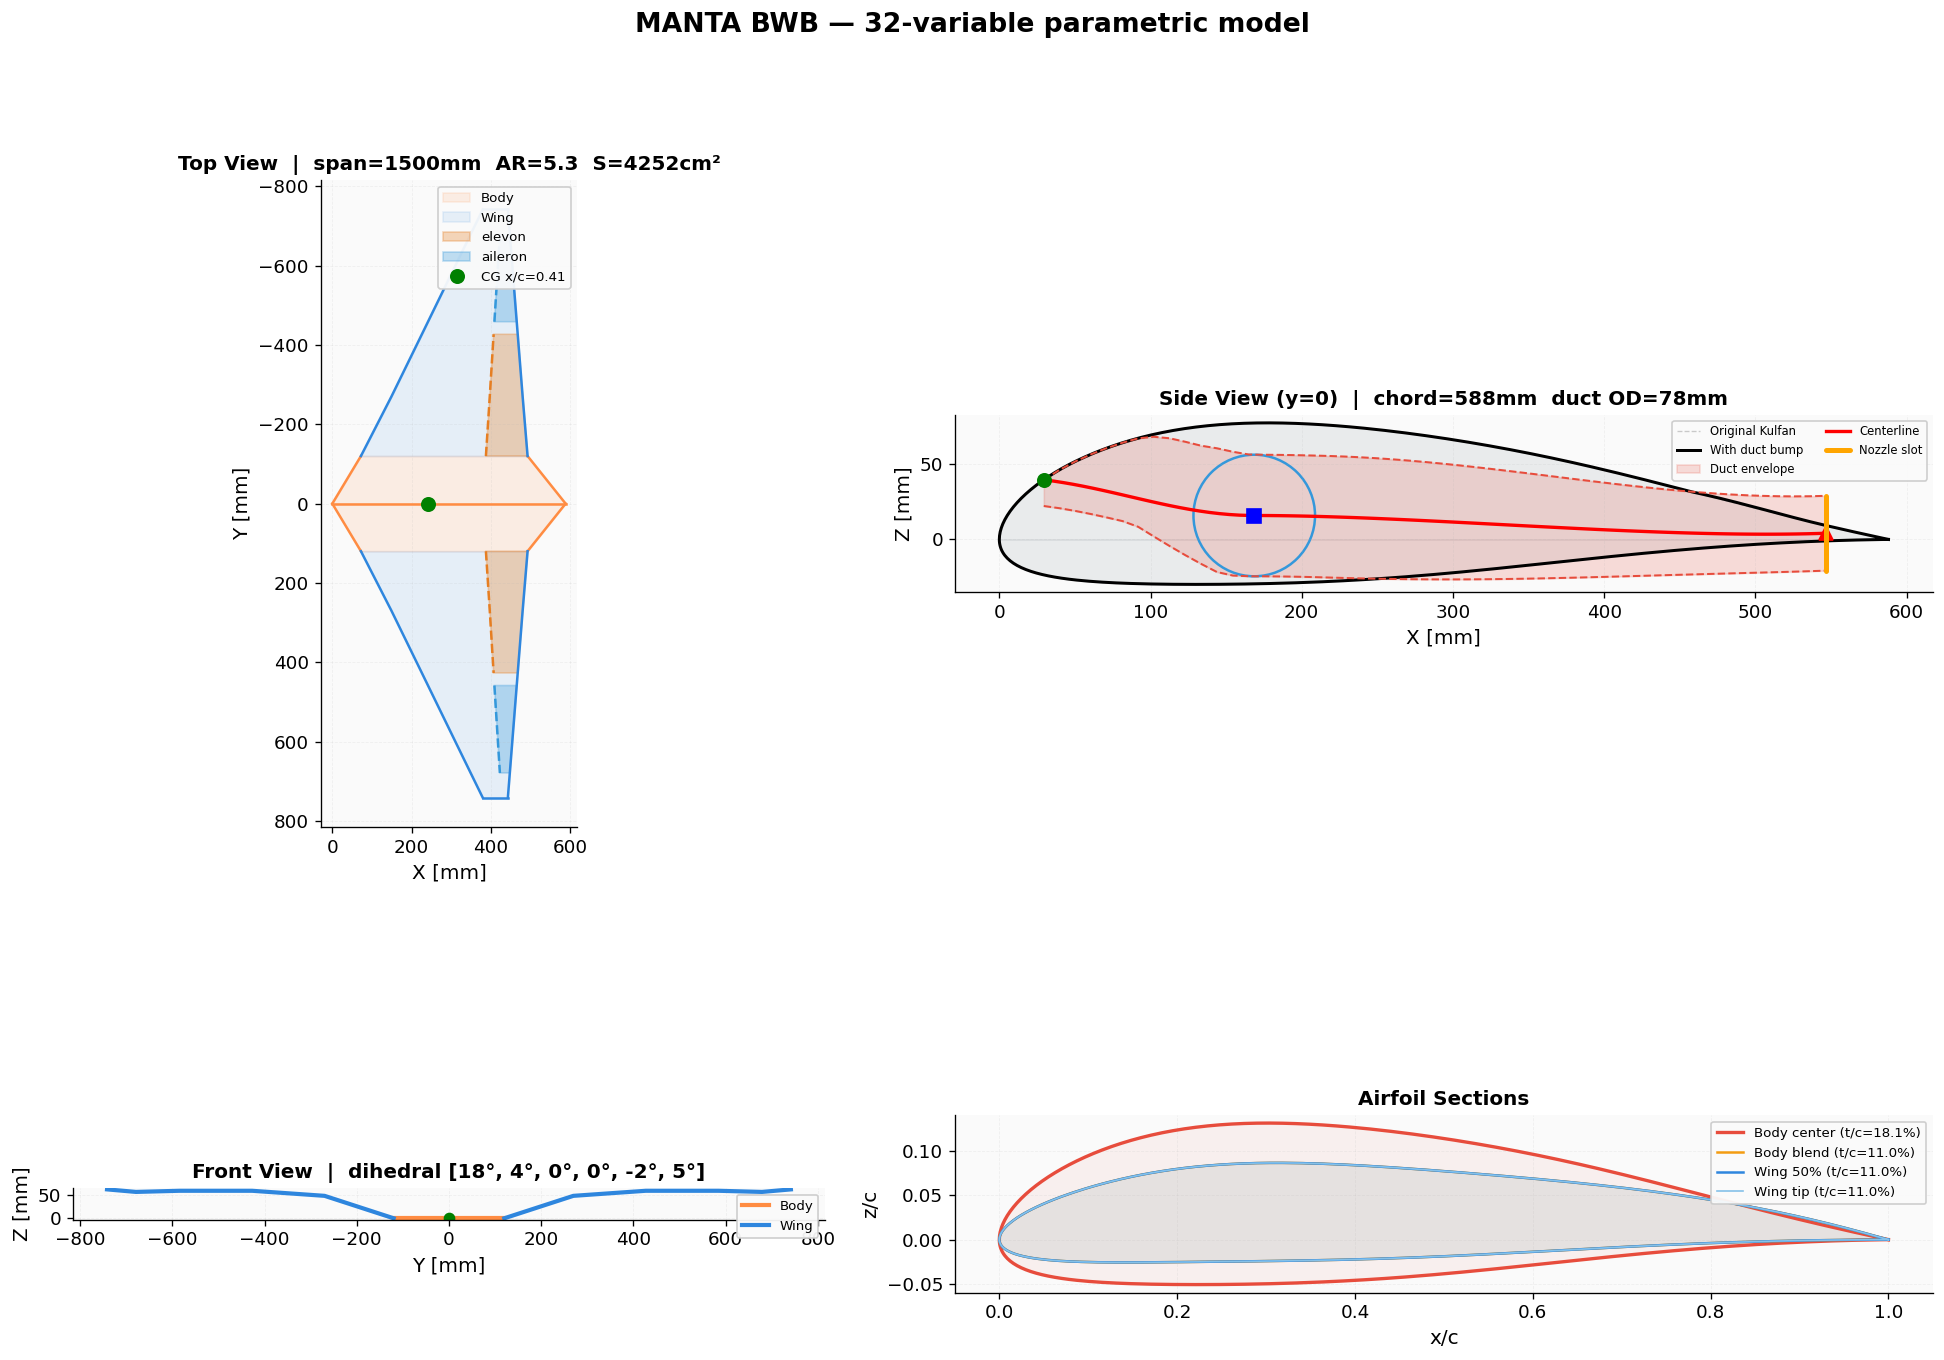

In [3]:
from src.visualization.plots import plot_cad_multiview
from src.geometry.control_surfaces import compute_control_surface_geometry
from src.systems.cg import compute_cg

placement = size_and_place_duct(params, EDF_70MM, config=duct_cfg)
geoms = compute_control_surface_geometry(params, cfg['controls'], n_spanwise=30)
cg = compute_cg(params, mission.battery_mass, mission.motor_mass,
                mission.avionics_mass, cfg['cg'])

fig = plot_cad_multiview(params, placement=placement,
                         controls=geoms, cg_data=cg)
fig.savefig('../output/cad_3view.png', dpi=150, bbox_inches='tight')
plt.show()

════════════════════════════════════════════════════════════
  Duct Performance Summary
════════════════════════════════════════════════════════════
  Pressure recovery : PR_in=0.930  PR_sd=0.998 (off/L=0.14)  PR_nz=0.960  PR_tot=0.891
  Thrust            : T_uninst=3.96N  T_inst=3.31N  (-16%)
  Nozzle TE drag    : CD=0.000489 (4.9 counts)
  Clearance         : min=-19.7mm  fits=False
  Thrust direction  : nozzle exit angle = -0.07° (physical frame, 0° = horizontal)
  Body twist        : 2.0° (compensated in nozzle Bezier)


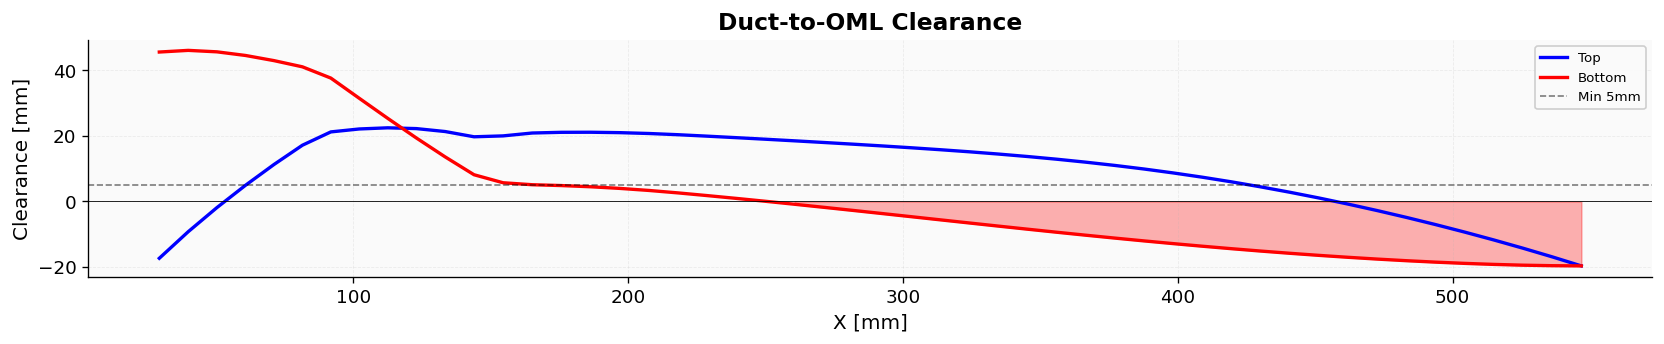

In [4]:
# ── Duct Performance & Clearance ──
from src.aero.drag import compute_nozzle_exit_drag
from src.propulsion.edf_model import thrust_at_speed
from src.propulsion.balance import compute_propulsion_balance
from src.propulsion.duct_aero import compute_duct_aero
from src.propulsion.duct_geometry import DuctSpine

_, clr_results = validate_duct_clearance(placement, params, min_clearance_mm=0.0)
duct_aero = compute_duct_aero(placement, EDF_70MM, params,
                               velocity=mission.velocity, rho=mission.density)
cd_nozzle = compute_nozzle_exit_drag(
    placement.exhaust_width, placement.exhaust_height, s_ref)
t_uninst = thrust_at_speed(EDF_70MM, mission.velocity)
prop = compute_propulsion_balance(2.0, mission.velocity, EDF_70MM,
                                   mission.battery, pr_total=duct_aero.pr_total)
min_clr = min(min(r.clearance_top_mm, r.clearance_bot_mm) for r in clr_results)

# Thrust direction verification
spine = DuctSpine(placement)
nozzle_angle = spine.exhaust_angle_physical_deg()

print(f"{'═'*60}")
print(f"  Duct Performance Summary")
print(f"{'═'*60}")
print(f"  Pressure recovery : PR_in={duct_aero.pr_intake:.3f}  PR_sd={duct_aero.pr_sduct:.3f} (off/L={duct_aero.sduct_offset_ratio:.2f})  PR_nz={duct_aero.pr_nozzle:.3f}  PR_tot={duct_aero.pr_total:.3f}")
print(f"  Thrust            : T_uninst={t_uninst:.2f}N  T_inst={prop['T_available']:.2f}N  (-{(1 - prop['T_available']/t_uninst)*100:.0f}%)")
print(f"  Nozzle TE drag    : CD={cd_nozzle:.6f} ({cd_nozzle*1e4:.1f} counts)")
print(f"  Clearance         : min={min_clr:.1f}mm  fits={min_clr >= 0}")
print(f"  Thrust direction  : nozzle exit angle = {nozzle_angle:.2f}° (physical frame, 0° = horizontal)")
print(f"  Body twist        : {params.body_twist:.1f}° (compensated in nozzle Bezier)")
if duct_aero.warnings:
    for w in duct_aero.warnings:
        print(f"  WARNING: {w}")

fig, ax = plt.subplots(figsize=(14, 3))
clr_x = [r.x_mm for r in clr_results]
ax.plot(clr_x, [r.clearance_top_mm for r in clr_results], 'b-', lw=2, label='Top')
ax.plot(clr_x, [r.clearance_bot_mm for r in clr_results], 'r-', lw=2, label='Bottom')
ax.axhline(0, color='k', lw=0.5)
ax.axhline(5.0, color='k', ls='--', lw=1, alpha=0.5, label='Min 5mm')
ax.fill_between(clr_x, [r.clearance_bot_mm for r in clr_results], 0,
                where=[r.clearance_bot_mm < 0 for r in clr_results], alpha=0.3, color='red')
ax.set_xlabel('X [mm]'); ax.set_ylabel('Clearance [mm]')
ax.set_title('Duct-to-OML Clearance', fontweight='bold')
ax.legend(fontsize=8, loc='upper right'); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()